In [2]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

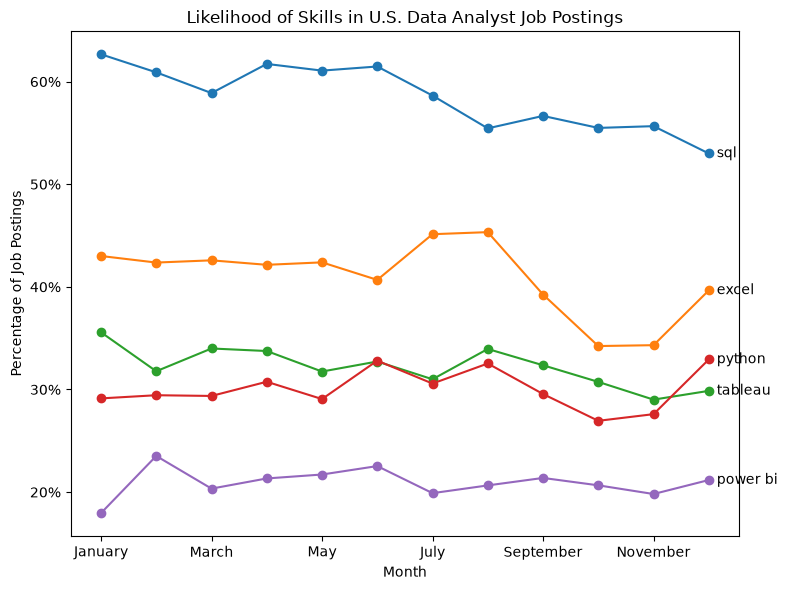

job_skills,sql,excel,tableau,python,power bi
job_posted_month,,,,,
January,62.665198,43.006608,35.572687,29.129956,17.951542
February,60.903427,42.367601,31.775701,29.439252,23.520249
March,58.883994,42.584435,33.994126,29.368576,20.337739
April,61.723886,42.147553,33.747261,30.752374,21.329438
May,61.072664,42.387543,31.747405,29.065744,21.712803
June,61.474731,40.679370,32.725766,32.808616,22.535211
July,58.638743,45.130890,30.994764,30.575916,19.895288
August,55.445545,45.332390,33.946252,32.531825,20.650636
September,56.658879,39.252336,32.359813,29.556075,21.378505


In [55]:

from matplotlib.ticker import PercentFormatter


## Skill count per month for data analysts
df_DA_US = df[(df['job_title'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

df_DA_US['job_posted_month'] = df_DA_US['job_posted_date'].dt.month_name()
df_DA_US['job_posted_month_no'] = df_DA_US['job_posted_date'].dt.month

month_order = (
    df_DA_US[['job_posted_month', 'job_posted_month_no']]
    .drop_duplicates()
    .sort_values('job_posted_month_no')
    ['job_posted_month']
)

monthly_job_totals = df_DA_US.groupby('job_posted_month').size()

# Explode job_skills column
df_DA_US_explode = df_DA_US.explode('job_skills')


df_skills_pivot = df_DA_US_explode.pivot_table(index='job_posted_month', 
                             columns='job_skills', 
                             values='job_title_short',
                             aggfunc='count',
                             fill_value=0,
                             margins=True, 
                             margins_name='Total')
df_skills_pivot = df_skills_pivot.drop(columns='Total')



df_skills_pivot_plot = df_skills_pivot.sort_values(by='Total', axis=1, ascending=False).iloc[:, 0:5]
df_skills_pivot_plot = df_skills_pivot_plot.div(monthly_job_totals,axis=0) * 100
df_skills_pivot_plot = df_skills_pivot_plot.drop(index='Total')
df_skills_pivot_plot = df_skills_pivot_plot.reindex(month_order)

ax = df_skills_pivot_plot.plot(
    kind='line',
    figsize=(8, 6),
    marker='o',
    legend=False
)

# Put skill name at the end of each line
for skill in df_skills_pivot_plot.columns:
    ax.text(
        len(df_skills_pivot_plot) - 1,
        df_skills_pivot_plot[skill].iloc[-1],
        f'  {skill}',
        va='center'
    )

# Show % on Y-axis
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))

# Titles and axis labels
ax.set_title('Likelihood of Skills in U.S. Data Analyst Job Postings')
ax.set_xlabel('Month')
ax.set_ylabel('Percentage of Job Postings')

plt.tight_layout()
plt.show()


df_skills_pivot_plot


